In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

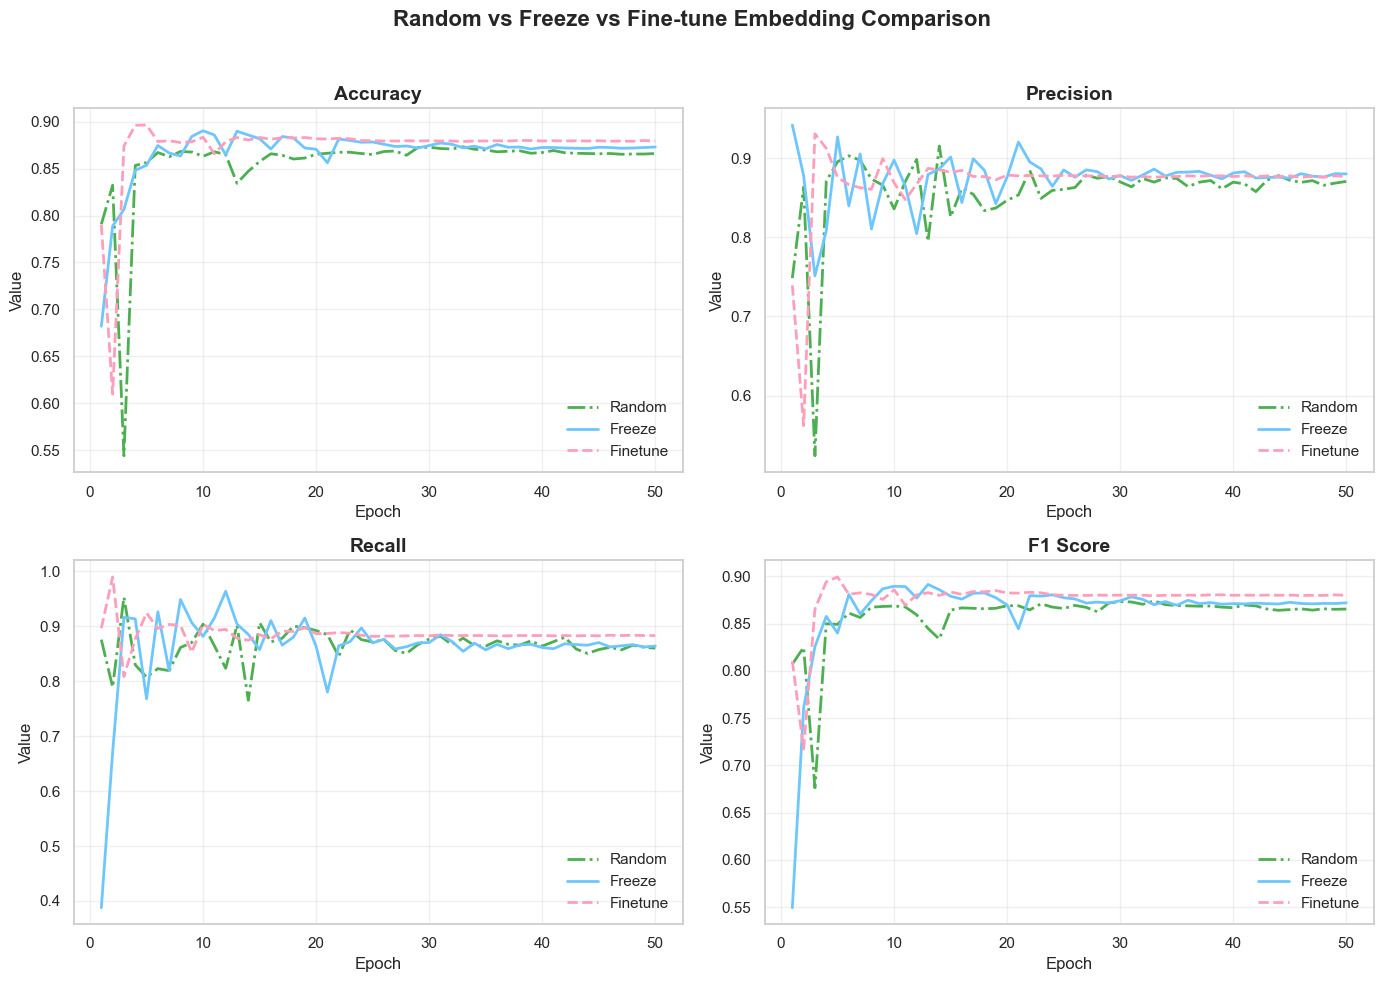

In [15]:
# Seaborn
sns.set(style="whitegrid")

# read data
freeze_history = pd.read_csv("freeze_training_history2.csv")
finetune_history = pd.read_csv("finetune_training_history2.csv")
random_history = pd.read_csv("lstm_training_history.csv")

metrics = ["val_acc", "val_prec", "val_rec", "val_f1"]
metric_names = {
    "val_acc": "Accuracy",
    "val_prec": "Precision", 
    "val_rec": "Recall",
    "val_f1": "F1 Score"
}

freeze_color = "#6EC6FF"
finetune_color = "#FF9EBB"
random_color = "#4CAF50" 

# 2×2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Random
    ax.plot(
        random_history["epoch"], random_history[metric],
        color=random_color, linestyle="-.", linewidth=2, label="Random"
    )
    
    # Freeze
    ax.plot(
        freeze_history["epoch"], freeze_history[metric],
        color=freeze_color, linestyle="-", linewidth=2, label="Freeze"
    )

    # Finetune
    ax.plot(
        finetune_history["epoch"], finetune_history[metric],
        color=finetune_color, linestyle="--", linewidth=2, label="Finetune"
    )

    ax.set_title(metric_names[metric], fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Value", fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)

plt.suptitle("Random vs Freeze vs Fine-tune Embedding Comparison", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("three_methods_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

Performance Results Summary:
                Model  Accuracy  Precision  Recall  F1-Score
0    Random Embedding    0.8624     0.8636  0.8608    0.8622
1     Word2Vec Frozen    0.8635     0.8767  0.8459    0.8610
2  Word2Vec Fine-tune    0.8717     0.8711  0.8725    0.8718


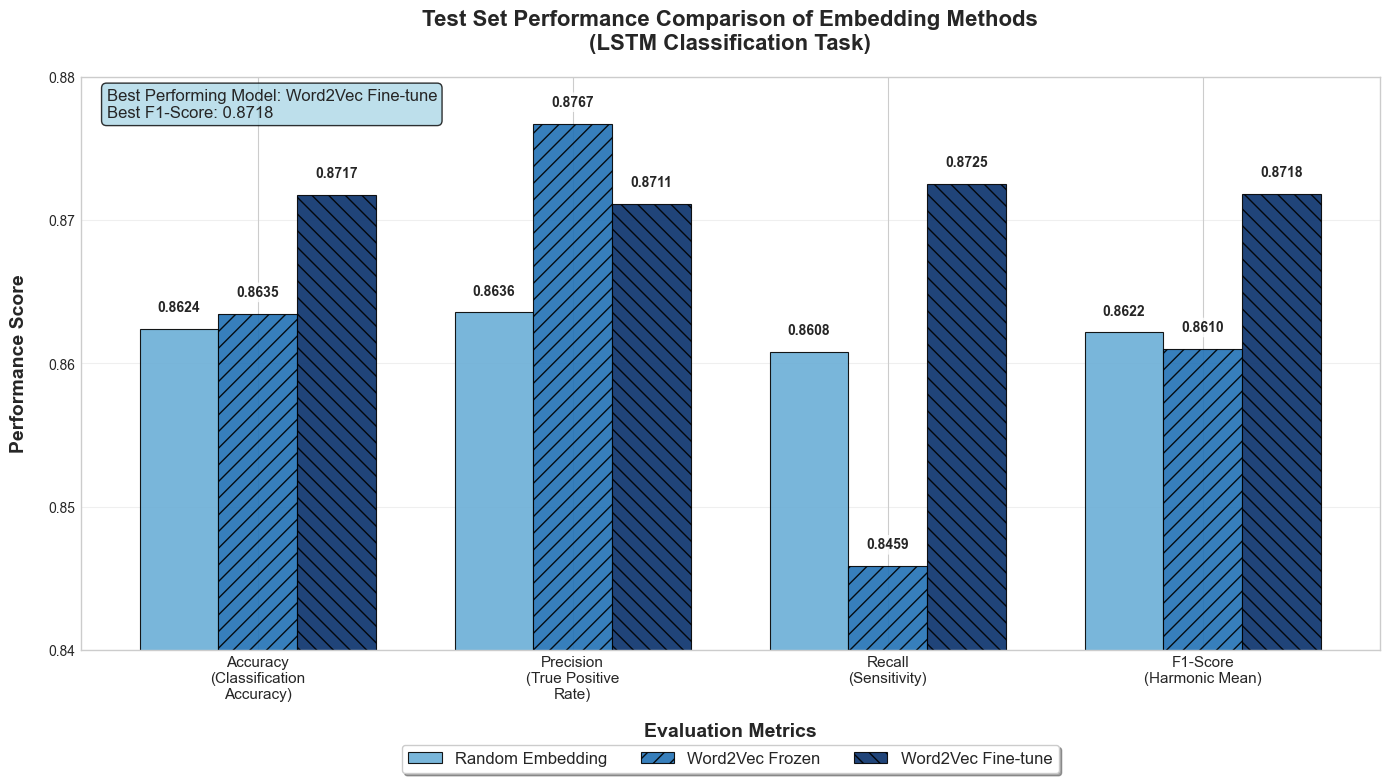


STATISTICAL ANALYSIS SUMMARY

Accuracy:
  Word2Vec Frozen: 0.8635 (+0.0011, +0.12%) ↑
  Word2Vec Fine-tune: 0.8717 (+0.0093, +1.08%) ↑

Precision:
  Word2Vec Frozen: 0.8767 (+0.0132, +1.52%) ↑
  Word2Vec Fine-tune: 0.8711 (+0.0076, +0.88%) ↑

Recall:
  Word2Vec Frozen: 0.8459 (-0.0149, -1.73%) ↓
  Word2Vec Fine-tune: 0.8725 (+0.0117, +1.36%) ↑

F1-Score:
  Word2Vec Frozen: 0.8610 (-0.0012, -0.13%) ↓
  Word2Vec Fine-tune: 0.8718 (+0.0097, +1.12%) ↑


In [2]:
# Set style for academic publication
plt.style.use('seaborn-v0_8-whitegrid')

# Read and process the data
random_data = pd.read_csv("lstm_test_results.csv")
word2vec_data = pd.read_csv("word2vec_test_results.csv")

# Process random embedding data
random_results = {
    'Model': 'Random Embedding',
    'Accuracy': random_data[random_data['metric'] == 'test_accuracy']['value'].values[0],
    'Precision': random_data[random_data['metric'] == 'test_precision']['value'].values[0],
    'Recall': random_data[random_data['metric'] == 'test_recall']['value'].values[0],
    'F1-Score': random_data[random_data['metric'] == 'test_f1']['value'].values[0]
}

# Process Word2Vec data
freeze_results = {
    'Model': 'Word2Vec Frozen',
    'Accuracy': word2vec_data[word2vec_data['Model'] == 'Word2Vec Frozen']['Accuracy'].values[0],
    'Precision': word2vec_data[word2vec_data['Model'] == 'Word2Vec Frozen']['Precision'].values[0],
    'Recall': word2vec_data[word2vec_data['Model'] == 'Word2Vec Frozen']['Recall'].values[0],
    'F1-Score': word2vec_data[word2vec_data['Model'] == 'Word2Vec Frozen']['F1'].values[0]
}

finetune_results = {
    'Model': 'Word2Vec Fine-tune', 
    'Accuracy': word2vec_data[word2vec_data['Model'] == 'Word2Vec Fine-tune']['Accuracy'].values[0],
    'Precision': word2vec_data[word2vec_data['Model'] == 'Word2Vec Fine-tune']['Precision'].values[0],
    'Recall': word2vec_data[word2vec_data['Model'] == 'Word2Vec Fine-tune']['Recall'].values[0],
    'F1-Score': word2vec_data[word2vec_data['Model'] == 'Word2Vec Fine-tune']['F1'].values[0]
}

# Create unified dataframe
results_df = pd.DataFrame([random_results, freeze_results, finetune_results])

# Melt the dataframe for plotting
melted_df = results_df.melt(id_vars=['Model'], 
                           value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                           var_name='Metric', 
                           value_name='Score')

print("Performance Results Summary:")
print(results_df.round(4))

# Create the grouped bar plot
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Define positions for grouped bars
x = np.arange(len(melted_df['Metric'].unique()))  # Metric positions
width = 0.25  # Width of each bar
models = melted_df['Model'].unique()

# Define blue color scheme with different depths
colors = ['#6BAED6', '#2171B5', '#08306B']  # Light blue, medium blue, dark blue
patterns = ['', '//', '\\\\']  # Solid, forward slash, backward slash

# Plot bars for each model
for i, model in enumerate(models):
    model_data = melted_df[melted_df['Model'] == model]
    positions = x + (i - 1) * width  # Center the groups
    bars = ax.bar(positions, model_data['Score'], width, 
                 label=model, color=colors[i], 
                 edgecolor='black', linewidth=0.8,
                 hatch=patterns[i], alpha=0.9)
    
    # Add value labels on top of bars - positioned closer to bars
    for bar, value in zip(bars, model_data['Score']):
        height = bar.get_height()
        # Position text closer to the top of the bar
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
               f'{value:.4f}', ha='center', va='bottom', 
               fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Customize the plot
ax.set_xlabel('Evaluation Metrics', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Performance Score', fontsize=14, fontweight='bold', labelpad=15)
ax.set_title('Test Set Performance Comparison of Embedding Methods\n(LSTM Classification Task)', 
             fontsize=16, fontweight='bold', pad=20)

# Set x-axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy\n(Classification\nAccuracy)', 
                   'Precision\n(True Positive\nRate)', 
                   'Recall\n(Sensitivity)', 
                   'F1-Score\n(Harmonic Mean)'], 
                  fontsize=11, ha='center')

# Adjust y-axis range to bring values closer to bars
ax.set_ylim(0.84, 0.88)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.01))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.002))

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

# Customize legend
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
                  ncol=3, frameon=True, fancybox=True, 
                  shadow=True, fontsize=12)

# Add some statistical annotations
best_f1_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_f1_score = results_df['F1-Score'].max()

ax.text(0.02, 0.98, f'Best Performing Model: {best_f1_model}\nBest F1-Score: {best_f1_score:.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Adjust layout and save
plt.tight_layout()
plt.savefig("embedding_methods_comparison.png", dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

# Additional statistical analysis
print("\n" + "="*70)
print("STATISTICAL ANALYSIS SUMMARY")
print("="*70)

# Calculate improvements over random embedding
random_baseline = results_df[results_df['Model'] == 'Random Embedding'].iloc[0]
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    print(f"\n{metric}:")
    for model in ['Word2Vec Frozen', 'Word2Vec Fine-tune']:
        model_score = results_df[results_df['Model'] == model][metric].values[0]
        improvement = model_score - random_baseline[metric]
        improvement_pct = (improvement / random_baseline[metric]) * 100
        trend = "↑" if improvement > 0 else "↓" if improvement < 0 else "→"
        print(f"  {model}: {model_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%) {trend}")